In [ ]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from torch import nn
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**1. Loading and analysis dataset**

In [462]:
dataset =  datasets.load_diabetes(scaled=False)

In [463]:
col = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X = pd.DataFrame(dataset.data, columns=col)
y = pd.DataFrame(dataset.target, columns=["disease progression"])

In [464]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


In [465]:
y

,disease progression
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [466]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [467]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000


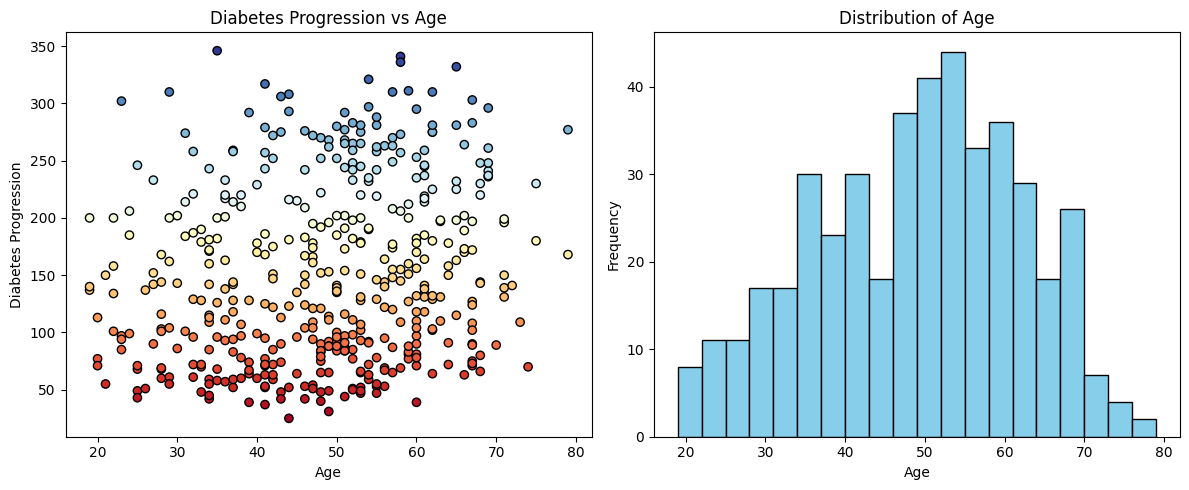

In [468]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 0], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs Age")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 0], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of Age")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

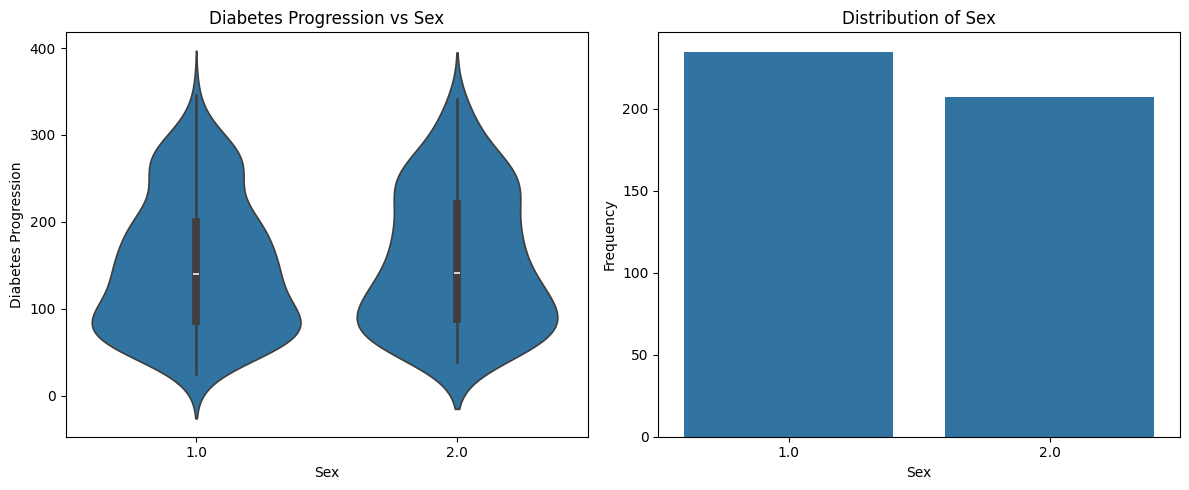

In [469]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


sns.violinplot(y=y.values.flatten(), x=X.iloc[:, 1], ax=ax[0])
ax[0].set_title("Diabetes Progression vs Sex")
ax[0].set_xlabel("Sex")
ax[0].set_ylabel("Diabetes Progression")


sns.countplot(x=X.iloc[:, 1], ax=ax[1])
ax[1].set_title("Distribution of Sex")
ax[1].set_xlabel("Sex")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

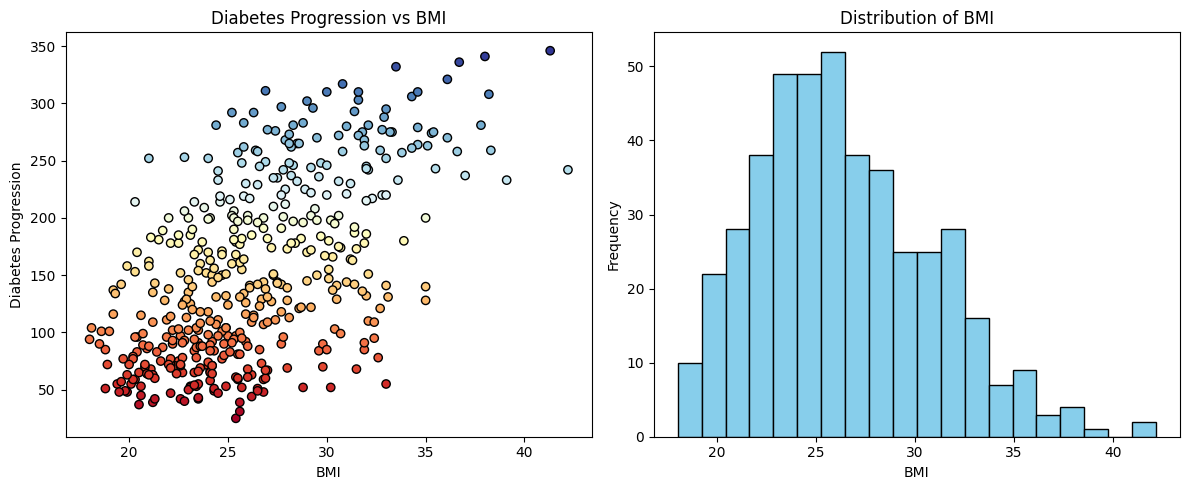

In [470]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 2], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs BMI")
ax[0].set_xlabel("BMI")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 2], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of BMI")
ax[1].set_xlabel("BMI")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

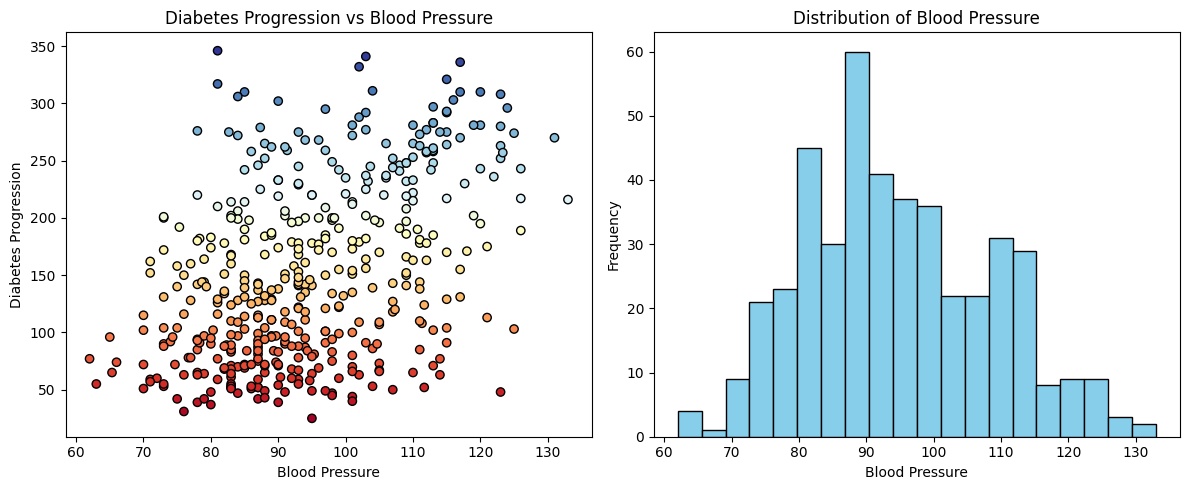

In [471]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 3], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs Blood Pressure")
ax[0].set_xlabel("Blood Pressure")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 3], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of Blood Pressure")
ax[1].set_xlabel("Blood Pressure")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

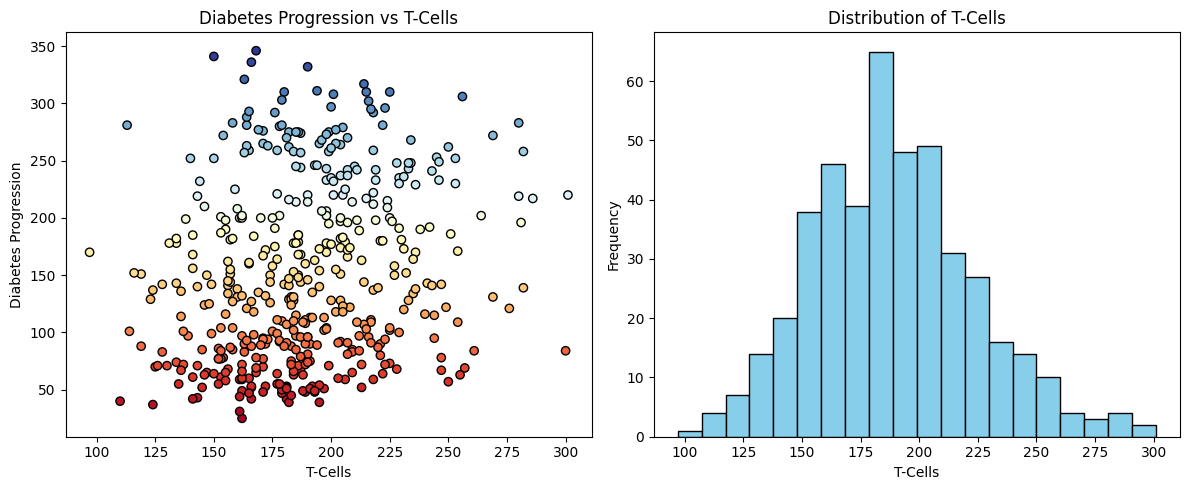

In [472]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 4], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs T-Cells")
ax[0].set_xlabel("T-Cells")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 4], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of T-Cells")
ax[1].set_xlabel("T-Cells")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

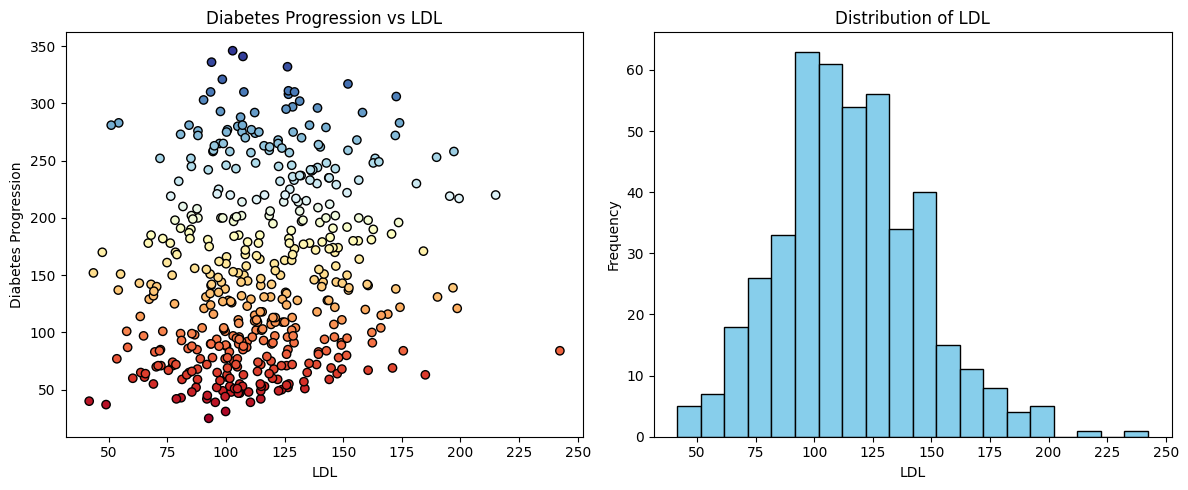

In [473]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 5], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs LDL")
ax[0].set_xlabel("LDL")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 5], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of LDL")
ax[1].set_xlabel("LDL")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

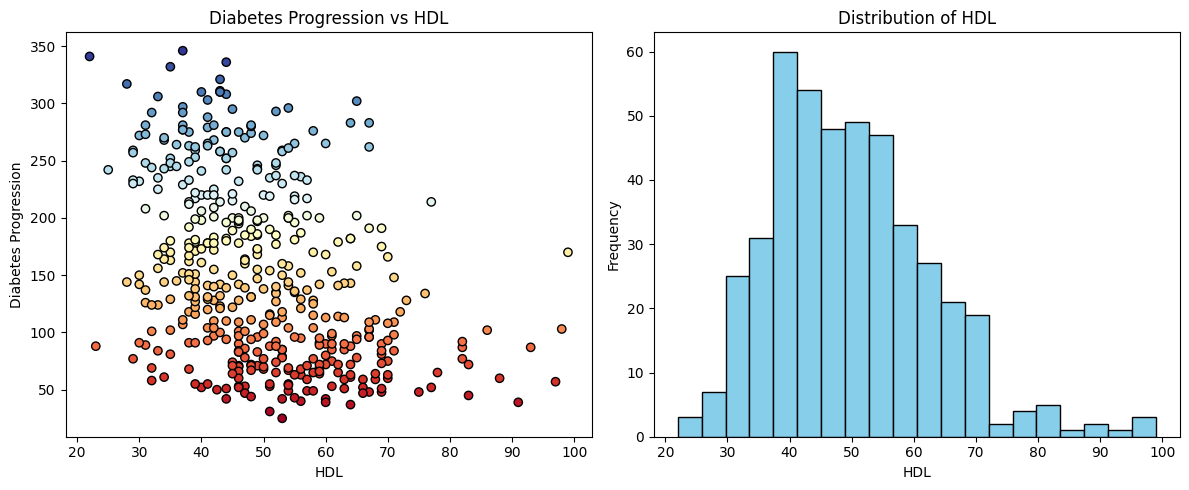

In [474]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 6], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs HDL")
ax[0].set_xlabel("HDL")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 6], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of HDL")
ax[1].set_xlabel("HDL")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

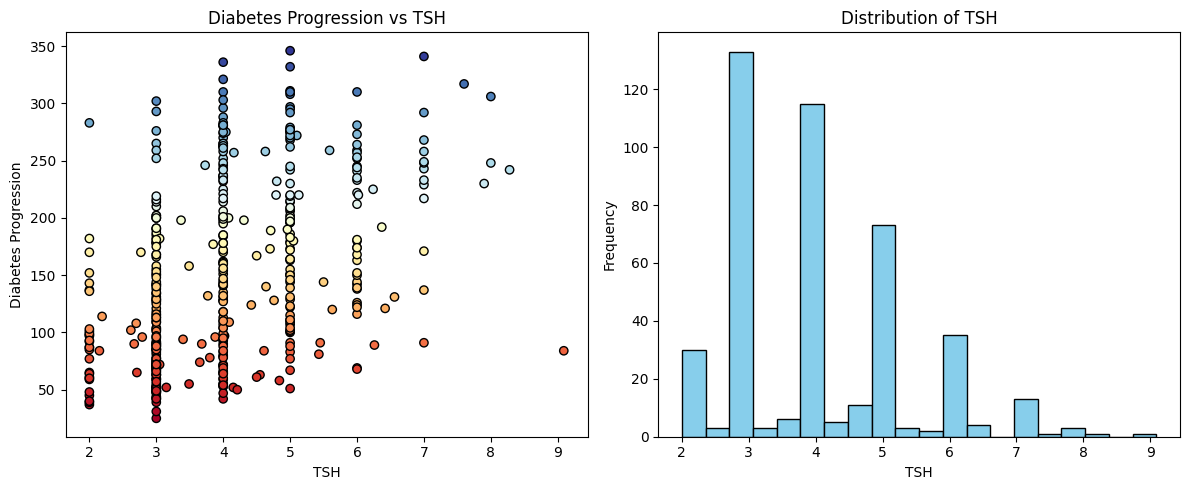

In [475]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 7], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs TSH")
ax[0].set_xlabel("TSH")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 7], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of TSH")
ax[1].set_xlabel("TSH")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

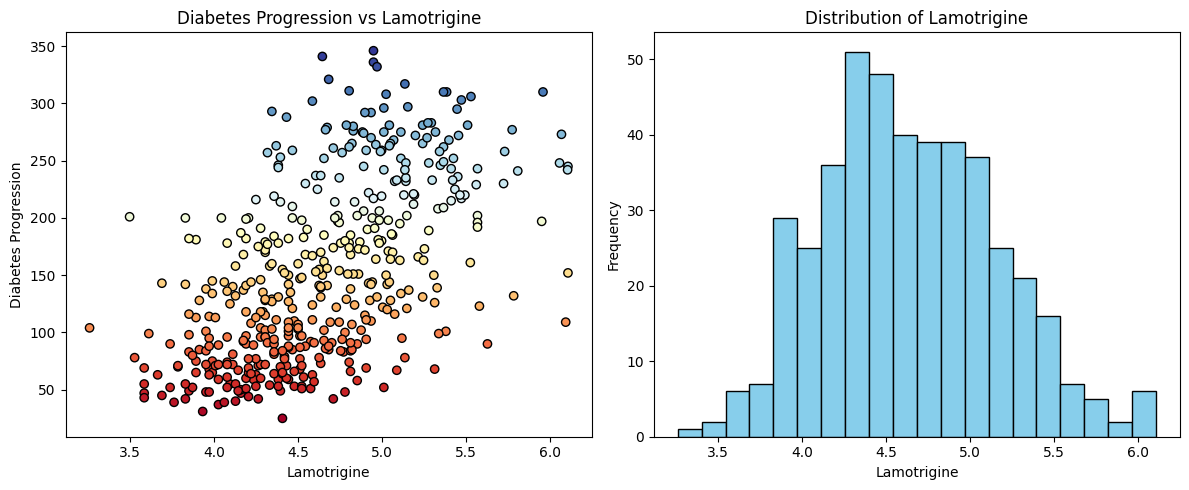

In [476]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 8], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs Lamotrigine")
ax[0].set_xlabel("Lamotrigine")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 8], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of Lamotrigine")
ax[1].set_xlabel("Lamotrigine")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

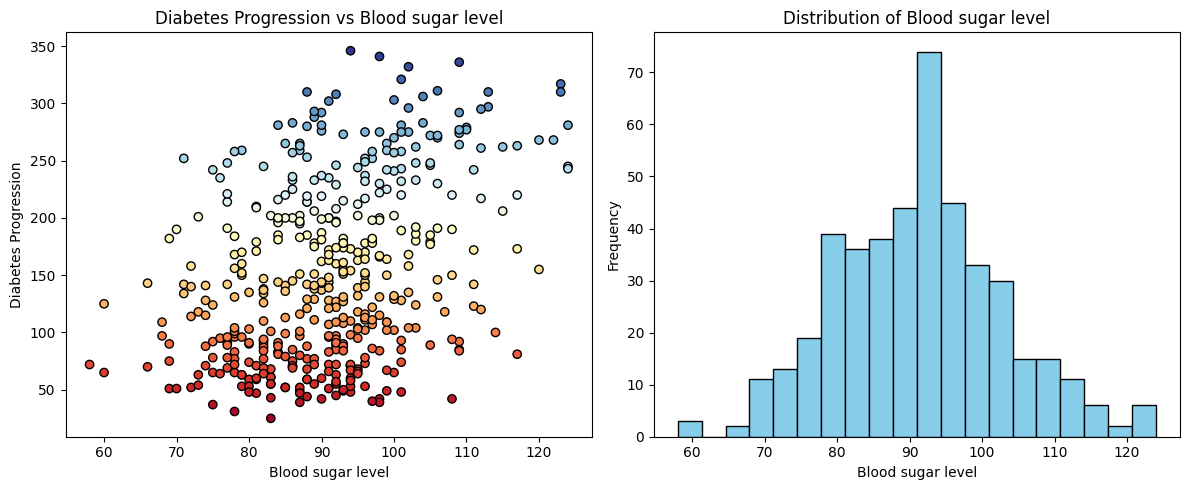

In [477]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X.iloc[:, 9], y.values.flatten(), c=y.values.flatten(), cmap=plt.cm.RdYlBu, edgecolor='k')
ax[0].set_title("Diabetes Progression vs Blood sugar level")
ax[0].set_xlabel("Blood sugar level")
ax[0].set_ylabel("Diabetes Progression")


ax[1].hist(X.iloc[:, 9], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Distribution of Blood sugar level")
ax[1].set_xlabel("Blood sugar level")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

After analyzing the dataset and visualizing the distributions, and given that the objective is to demonstrate the implementation of a PyTorch-based algorithm rather than optimize model performance, the following preprocessing decisions were made:
- The dataset contains no missing values, therefore no imputation is required.
- All features are already in appropriate numeric formats, so no type conversion is necessary.
- Feature standardization will be applied prior to model training.
- The dataset contains no categorical variables, eliminating the need for encoding techniques.
- Feature engineering is not applied, as improving predictive performance is not the primary goal.
- No outliers were detected, therefore no outlier handling procedures are required.

**2. Preprocessing data**

Since linear regression and neural network algorithms will be used, standard scaling is the most appropriate method for data preprocessing.

In [478]:
X = dataset.data
y = dataset.target

In [479]:
y.shape

(442,)

In [480]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [481]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [482]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42)

In [483]:
len(X_train), len(X_test), len(y_train), len(y_test)

(353, 89, 353, 89)

**3. A comparative analysis of two linear models implemented in PyTorch**

The first step of the project will involve analyzing two different approaches to defining a Linear Regression model in PyTorch.

In [484]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))
    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.weights * x + self.bias
    

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [485]:
torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_2 = LinearRegressionModelV2()

**3.1 Choosing a Loss Function and Optimizer**

During this project, two different loss functions will be used to evaluate the models.

In [486]:
loss_fn = nn.L1Loss()
loss_mse = nn.MSELoss()
optimizer_1 = torch.optim.SGD(params = model_1.parameters(),lr=0.3)
optimizer_2 = torch.optim.SGD(params = model_2.parameters(),lr=0.3)

**3.2 Loop for first model and first optimizer!**

In [487]:
X_train_bmi = X_train[:, 2]
X_test_bmi = X_test[:, 2]

In [488]:
torch.manual_seed(42)

epochs = 2000
epoch_count_1 = []
loss_values_1 = []
test_loss_values_1 = []

for epoch in range(epochs):
    model_1.train()
    
    y_pred_1 = model_1(X_train_bmi)
    
    loss_1 = loss_fn(y_pred_1, y_train)
    
    optimizer_1.zero_grad()
    
    loss_1.backward()
    
    optimizer_1.step()

    model_1.eval()


    with torch.inference_mode():
        test_pred_1 = model_1(X_test_bmi)
        test_loss_1 = loss_fn(test_pred_1, y_test)

    if epoch % 10 == 0:
        epoch_count_1.append(epoch)
        loss_values_1.append(loss_1.item())
        test_loss_values_1.append(test_loss_1.item())

    y_pred_1 = test_pred_1

**3.3 Loop for second model and second optimizer**

In [489]:
X_train_bmi = X_train_bmi.reshape(X_train.shape[0], -1)
X_test_bmi = X_test_bmi.reshape(X_test.shape[0], -1)

In [ ]:
torch.manual_seed(42)

epochs = 2000 
epoch_count_2 = []
loss_values_2 = []
test_loss_values_2 = []

for epoch in range(epochs):
    model_2.train()
    
    y_pred_2 = model_2(X_train_bmi)
    
    loss_2 = loss_fn(y_pred_2, y_train)
    
    optimizer_2.zero_grad()
    
    loss_2.backward()
    
    optimizer_2.step()

    model_2.eval()

    with torch.inference_mode():
        test_pred_2 = model_2(X_test_bmi)
        test_loss_2 = loss_fn(test_pred_2, y_test)

    if epoch % 10 == 0:
        epoch_count_2.append(epoch)
        loss_values_2.append(loss_2.item())
        test_loss_values_2.append(test_loss_2.item())

    y_pred_2 = test_pred_2

**3.4 Plotting graphs**

First model

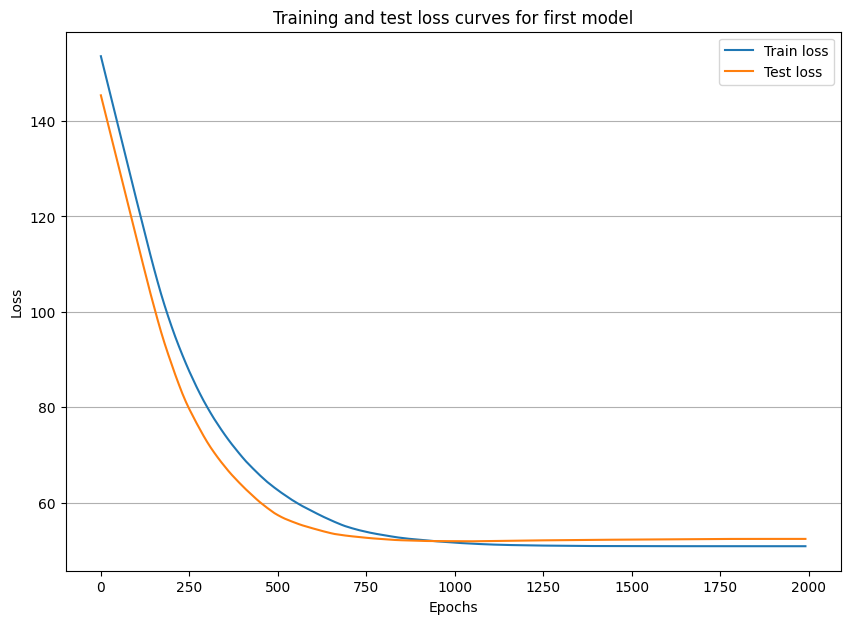

In [491]:
plt.figure(figsize=(10, 7))
plt.plot(epoch_count_1, np.array(torch.tensor(loss_values_1).numpy()), label="Train loss")
plt.plot(epoch_count_1, np.array(torch.tensor(test_loss_values_1).numpy()), label="Test loss")
plt.title("Training and test loss curves for first model")
plt.grid(visible=True, axis="y")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend() 
plt.show()

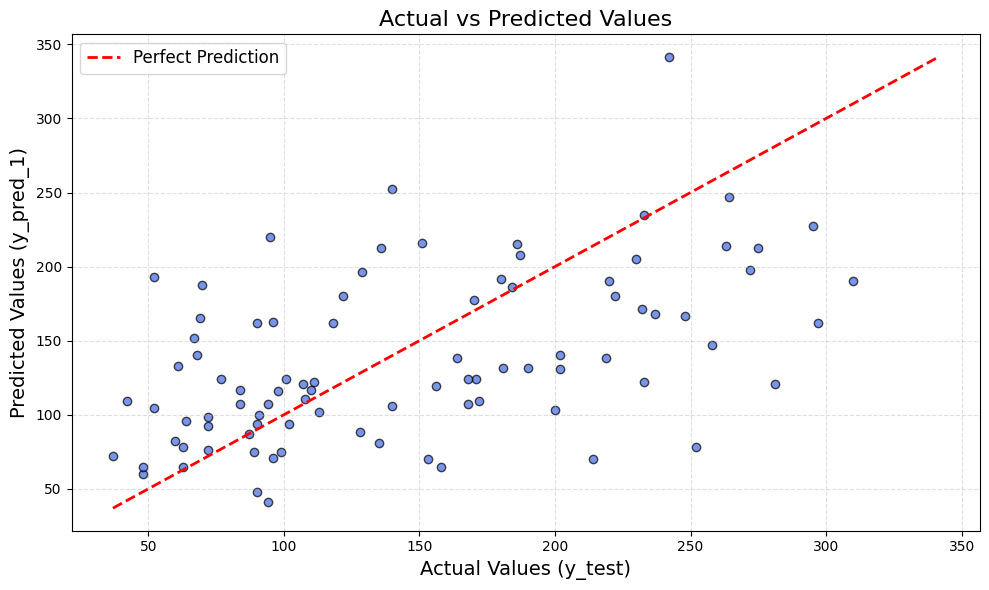

In [492]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_1.detach().numpy(), color="royalblue", alpha=0.7, edgecolor="black")

min_val = min(y_test.min(),y_pred_1.detach().numpy().min())
max_val = max(y_test.max(), y_pred_1.detach().numpy().max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2,
         label="Perfect Prediction")

plt.title("Actual vs Predicted Values", fontsize=16)
plt.xlabel("Actual Values (y_test)", fontsize=14)
plt.ylabel("Predicted Values (y_pred_1)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

As illustrated in the graph, the linear model based on a single feature (BMI) does not provide highly accurate predictions.

Second model

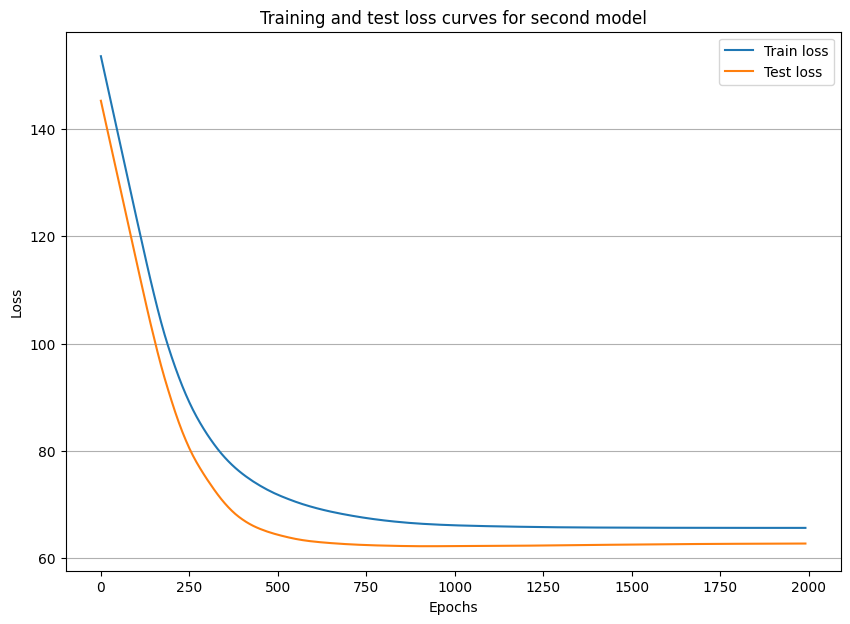

In [493]:
plt.figure(figsize=(10, 7))
plt.plot(epoch_count_2, np.array(torch.tensor(loss_values_2).numpy()), label="Train loss")
plt.plot(epoch_count_2, np.array(torch.tensor(test_loss_values_2).numpy()), label="Test loss")
plt.title("Training and test loss curves for second model")
plt.grid(visible=True, axis="y")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

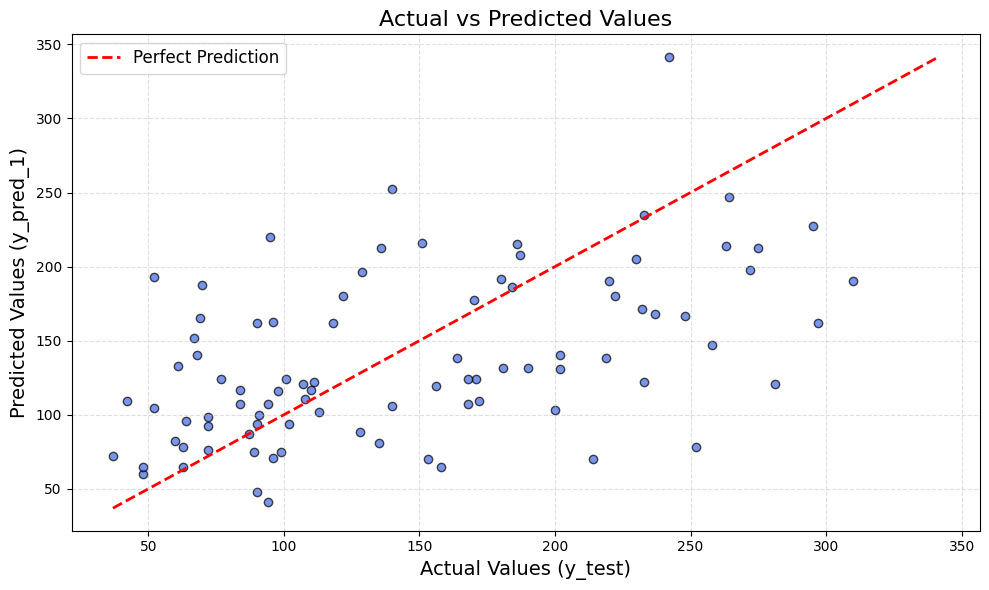

In [494]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_1.detach().numpy(), color="royalblue", alpha=0.7, edgecolor="black")

min_val = min(y_test.min(),y_pred_1.detach().numpy().min())
max_val = max(y_test.max(), y_pred_1.detach().numpy().max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2,
         label="Perfect Prediction")

plt.title("Actual vs Predicted Values", fontsize=16)
plt.xlabel("Actual Values (y_test)", fontsize=14)
plt.ylabel("Predicted Values (y_pred_1)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

As illustrated in the graph, the second linear model, which also uses only a single feature (BMI), fails to provide highly accurate predictions.

**4. Pytorch Neural Network Model**


In [495]:
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)


This model is:
- Feedforward Neural Network
- Multilayer Perceptron (MLP)
- Uses 2 hidden layers
- Uses ReLU activation
- Suitable for regression problems

In [496]:
class NeuralNetworkModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer_stack(x)
    

In [497]:
torch.manual_seed(42)
model_all = NeuralNetworkModel(input_features=10, output_features=1, hidden_units=512)

**4.1. Choosing a Loss Function and Optimizer**

For training this model, the Mean Squared Error (MSELoss) is used as the loss function, while the Adam optimizer is used to update the model parameters during training.

In [498]:
loss_fn_all = nn.MSELoss()
optimizer_all = torch.optim.Adam(params = model_all.parameters(),lr=0.003)

**4.2 Loop for neural network model!**

In [499]:
torch.manual_seed(42)

epochs = 1000
epoch_count_all = []
loss_values_all = []
test_loss_values_all = []

for epoch in range(epochs):
    model_all.train()
    
    y_pred_all = model_all(X_train)
    
    loss_all = loss_fn_all(y_pred_all, y_train)
    
    optimizer_all.zero_grad()
    
    loss_all.backward()
    
    optimizer_all.step()

    model_all.eval()


    with torch.inference_mode():
        test_pred_all = model_all(X_test)
        test_loss_all = loss_fn_all(test_pred_all, y_test)

    if epoch % 10 == 0:
        epoch_count_all.append(epoch)
        loss_values_all.append(loss_all.item())
        test_loss_values_all.append(test_loss_all.item())

    y_pred_all = test_pred_all


**4.3 Plotting graphs**

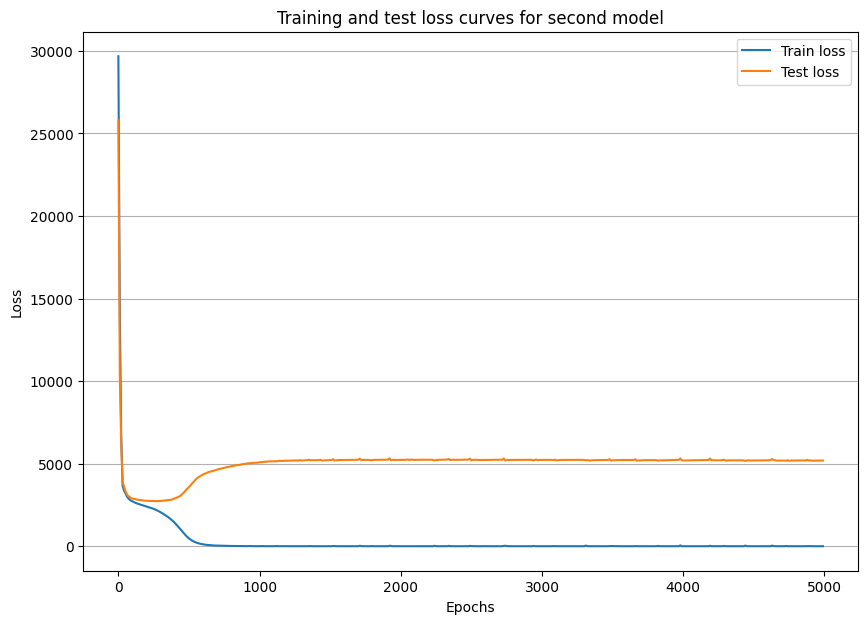

In [500]:
plt.figure(figsize=(10, 7))
plt.plot(epoch_count_all, np.array(torch.tensor(loss_values_all).numpy()), label="Train loss")
plt.plot(epoch_count_all, np.array(torch.tensor(test_loss_values_all).numpy()), label="Test loss")
plt.title("Training and test loss curves for second model")
plt.grid(visible=True, axis="y")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

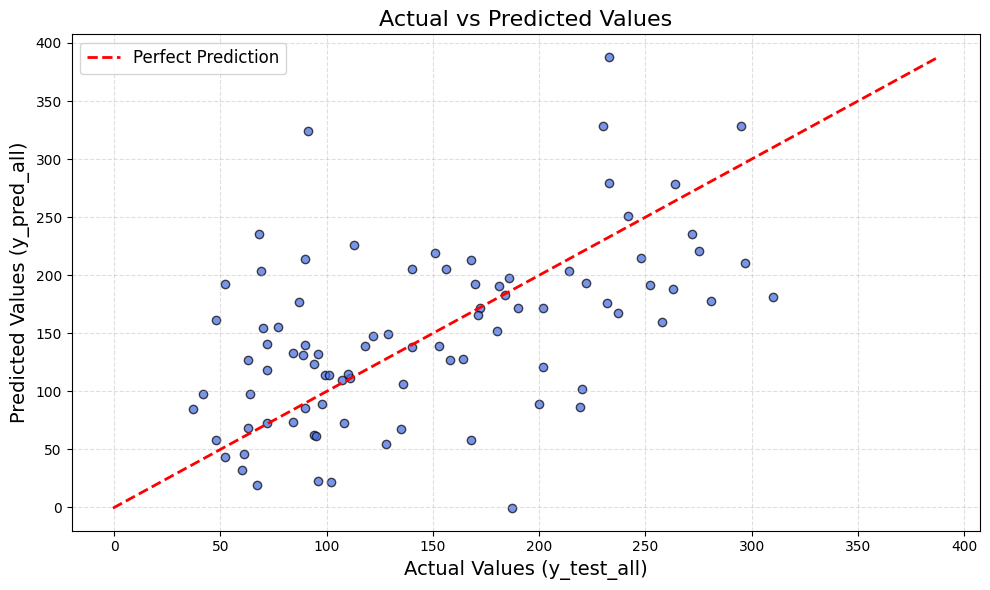

In [501]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_all.detach().numpy(), color="royalblue", alpha=0.7, edgecolor="black")

min_val = min(y_test.min(),y_pred_all.detach().numpy().min())
max_val = max(y_test.max(), y_pred_all.detach().numpy().max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2,
         label="Perfect Prediction")

plt.title("Actual vs Predicted Values", fontsize=16)
plt.xlabel("Actual Values (y_test_all)", fontsize=14)
plt.ylabel("Predicted Values (y_pred_all)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

As illustrated in the graph, the neural network model using all available features does not achieve highly accurate predictions.